In [3]:
from google.colab import files
uploaded = files.upload()

Saving screen_time_data_150.csv to screen_time_data_150 (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("screen_time_data_150.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
   Student_ID  Screen_Time  Productivity  Stress_Level  Sleep_Quality
0           1            8             2             7              1
1           2            5             6             6              4
2           3            9             1             8              1
3           4            6             5             7              5
4           5            8             1             8              2

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Student_ID     150 non-null    int64
 1   Screen_Time    150 non-null    int64
 2   Productivity   150 non-null    int64
 3   Stress_Level   150 non-null    int64
 4   Sleep_Quality  150 non-null    int64
dtypes: int64(5)
memory usage: 6.0 KB
None


In [6]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Student_ID  Screen_Time  Productivity  Stress_Level  Sleep_Quality
count  150.000000   150.000000    150.000000    150.000000     150.000000
mean    75.500000     6.300000      3.853333      6.253333       3.820000
std     43.445368     2.633675      2.539319      2.637333       2.546402
min      1.000000     2.000000      1.000000      1.000000       1.000000
25%     38.250000     4.000000      1.000000      4.000000       1.000000
50%     75.500000     6.000000      3.500000      6.000000       3.000000
75%    112.750000     9.000000      6.000000      9.000000       6.000000
max    150.000000    10.000000      9.000000     10.000000       9.000000


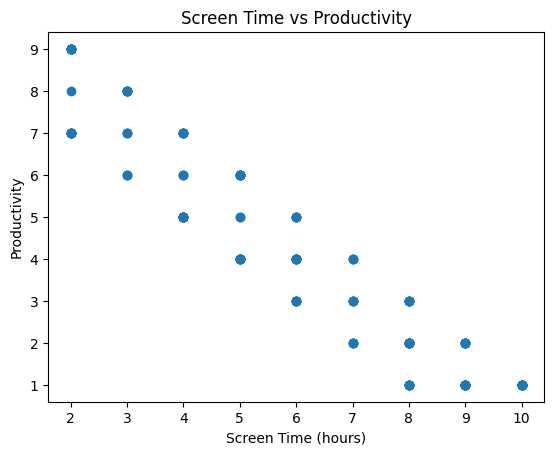

In [7]:
plt.figure()
plt.scatter(df["Screen_Time"], df["Productivity"])
plt.xlabel("Screen Time (hours)")
plt.ylabel("Productivity")
plt.title("Screen Time vs Productivity")
plt.show()

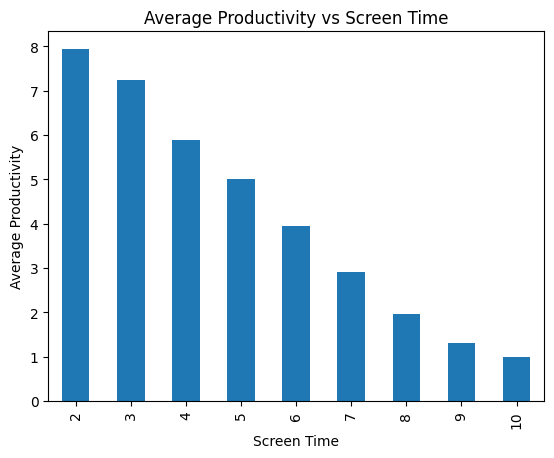

In [8]:
df_group = df.groupby("Screen_Time").mean()

plt.figure()
df_group["Productivity"].plot(kind="bar")
plt.xlabel("Screen Time")
plt.ylabel("Average Productivity")
plt.title("Average Productivity vs Screen Time")
plt.show()

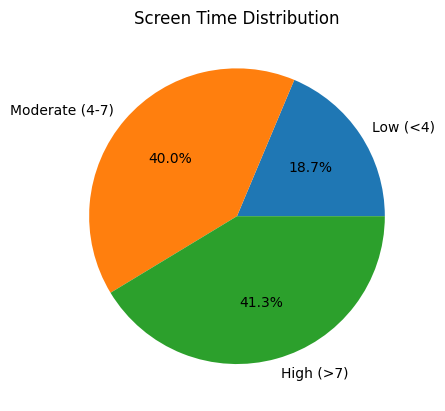

In [10]:
labels = ["Low (<4)", "Moderate (4-7)", "High (>7)"]

low = len(df[df["Screen_Time"] < 4])
moderate = len(df[(df["Screen_Time"] >= 4) & (df["Screen_Time"] <= 7)])
high = len(df[df["Screen_Time"] > 7])

sizes = [low, moderate, high]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Screen Time Distribution")
plt.show()

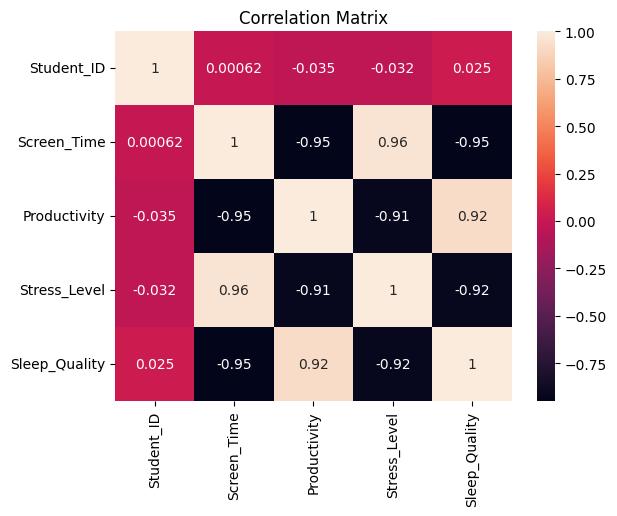

In [11]:
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df[["Screen_Time"]]
y = df["Productivity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.6065537363153637
R2 Score: 0.9102288500766605


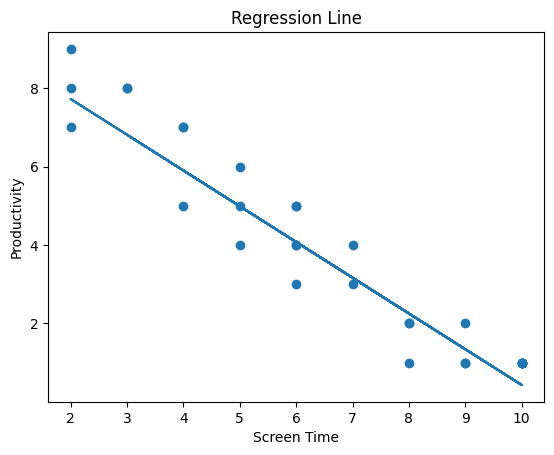

In [16]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Screen Time")
plt.ylabel("Productivity")
plt.title("Regression Line")
plt.show()